In [1]:
import pandas as pd
import numpy as np
import math
import scipy.stats as stats
from pathlib import Path
from results.topology_results import TopologyResults

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")



In [2]:
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/20260206/batch_20260206_21-45-57").resolve()

# Find all topology folders
TOPOLOGY_FOLDERS = sorted([d for d in PATH_TO_RESULTS_PARENT_FOLDER.iterdir() if d.is_dir()])
print(f"Found {len(TOPOLOGY_FOLDERS)} topologies to analyze: {[t.name for t in TOPOLOGY_FOLDERS]}")

# Metrics configuration for statistics printing
METRICS_CONFIG = [
    ("pdr", "PDR"), 
    ("latency_ms", "Latency [ms]"), 
    ("hop_stretch", "Hop Stretch")
]

Found 5 topologies to analyze: ['grid_20N', 'linear_20N', 'random_20N', 'ring_20N', 'star_20N']


In [3]:
# --- HELPER
def compute_ci(data, confidence=0.95):
    """Computes Mean and 95% CI Margin."""
    a = 1.0 * np.array(data)
    n = len(a)
    if n < 2: return np.mean(a), np.mean(a), np.mean(a), 0.0
    m = np.mean(a)
    se = stats.sem(a) # sem is std_dev/sqrt(n)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h, h  # Mean, Lower, Upper, Margin

In [4]:
# DATA PROCESSING
all_results_list = []
all_stats_list = []

for topo_folder in TOPOLOGY_FOLDERS:
    topo_name = topo_folder.name
    print(f"Processing Topology: {topo_name}...")
    
    # LOAD RESULTS (PDR, LATENCY)
    topo_results = TopologyResults.from_folder(topo_folder)
    data_list = []
    
    for channel_res in topo_results.channels: 
        for rep in channel_res.repetitions: 
            # PDR data may be missing if the channel has no connectivity
            pdr_val = rep.pdr_df.delivered.mean() if rep.pdr_df is not None and not rep.pdr_df.empty else 0
            
            # Latency also might be None or empty
            latency_val = None
            if rep.latency_df is not None and not rep.latency_df.empty:
                latency_val = rep.latency_df.latency.mean()
            
            data_list.append({
                "topology": topo_name,
                "channel_id": channel_res.channel_type,
                "rep_id": rep.id,
                "pdr": pdr_val,
                "latency": latency_val,
            })
    
    # Create df for standard results
    df_std = pd.DataFrame(data_list)

    # LOAD HOP STRETCH RESULTS FROM EXTERNAL CSV
    hs_topo_folder = (
        PATH_TO_RESULTS_PARENT_FOLDER.parent
        / "processed_results"
        / PATH_TO_RESULTS_PARENT_FOLDER.name
        / "hop_stretch"
        / topo_name
    )

    hs_ch_dfs = []
    
    # Iterate assuming the folder exists and has content
    if hs_topo_folder.exists():
        for channel_dir in hs_topo_folder.iterdir():
            if not channel_dir.is_dir(): continue

            hs_file = channel_dir / "hop_stretch.csv"
            
            try:
                hs_ch_df = pd.read_csv(hs_file)
                # Group hop stretches by repetition ID. Aggregate mean per repetition.
                hs_ch_df = (
                    hs_ch_df.groupby("id")["hop_stretch"]
                    .mean()
                    .reset_index()
                    .rename(columns={"id": "rep_id"})
                )
                hs_ch_df["channel_id"] = channel_dir.name 
                hs_ch_dfs.append(hs_ch_df) 
            except Exception as e:
                print(f"  [WARNING] Error reading HS file {hs_file}: {e}")
    
    # MERGE AND PREPROCESS
    if hs_ch_dfs:
        df_hs = pd.concat(hs_ch_dfs, ignore_index=True)
        topo_df = df_std.merge(df_hs, on=["channel_id", "rep_id"], how="left")
    else:
        print(f"  [INFO] No Hop Stretch data found for {topo_name}")
        topo_df = df_std
        topo_df["hop_stretch"] = np.nan

    # Calculate Latency in milliseconds
    topo_df["latency_ms"] = topo_df["latency"] * 1000 

    # COMPUTE STATISTICS
    unique_channels = topo_df["channel_id"].unique()
    
    for channel in unique_channels:
        subset = topo_df[topo_df["channel_id"] == channel]
        row = {"Topology": topo_name, "Channel": channel}
        
        for col_name, display_name in METRICS_CONFIG:
            data = subset[col_name].dropna()
            
            if len(data) > 1:
                mean, lower, upper, margin = compute_ci(data)
                row[f"{col_name}_mean"] = mean
                row[f"{col_name}_margin"] = margin
                row[display_name] = f"{mean:.3f} ± {margin:.3f}"
            else:
                row[f"{col_name}_mean"] = np.nan
                row[f"{col_name}_margin"] = 0
                row[display_name] = "N/A"
        
        all_stats_list.append(row)

    # Add the complete dataframe for this topology to the global list
    all_results_list.append(topo_df)


# --- FINAL AGGREGATION ---
all_results_df = pd.concat(all_results_list, ignore_index=True)
all_stats_df = pd.DataFrame(all_stats_list)

print("="*100)
print(f"GLOBAL PROCESSING COMPLETE. Total records processed: {len(all_results_df)}")
print("="*100 + "\n")

# Print Summary Table
print("="*100)
print(f"STATISTICS SUMMARY")
print("="*100)
display_cols = ["Topology", "Channel"] + [m[1] for m in METRICS_CONFIG]
print(all_stats_df[display_cols].to_string(index=False))

Processing Topology: grid_20N...
Processing Topology: linear_20N...
Processing Topology: random_20N...
Processing Topology: ring_20N...
Processing Topology: star_20N...
  [WARNING] Error reading HS file /home/damole/Documents/develop/SPE-project/results/20260206/processed_results/batch_20260206_21-45-57/hop_stretch/star_20N/stable_high_pl/hop_stretch.csv: 'Column not found: hop_stretch'
GLOBAL PROCESSING COMPLETE. Total records processed: 3000

STATISTICS SUMMARY
  Topology        Channel           PDR   Latency [ms]   Hop Stretch
  grid_20N          lossy 0.856 ± 0.011 11.543 ± 0.266 2.729 ± 0.025
  grid_20N  stable_mid_pl 0.879 ± 0.009 11.048 ± 0.253 2.808 ± 0.019
  grid_20N stable_high_pl 0.671 ± 0.009 22.470 ± 0.263 2.109 ± 0.019
  grid_20N       unstable 0.610 ± 0.013 22.590 ± 0.389 1.982 ± 0.032
  grid_20N         stable 0.960 ± 0.003  6.728 ± 0.031 2.305 ± 0.020
  grid_20N          ideal 0.965 ± 0.002  6.669 ± 0.029 2.250 ± 0.016
linear_20N          lossy 0.846 ± 0.009 14.101 ± 

In [5]:
# PLOT SETUP
sns.set_theme(style="whitegrid", palette="bright")

# Grid Size
num_topos = len(TOPOLOGY_FOLDERS)
cols = 2 
rows = math.ceil(num_topos / cols)

# SETTINGS
global_channels = sorted(all_results_df["channel_id"].unique()) # set channel order for all plots
global_palette = sns.color_palette("bright", n_colors=len(global_channels)) #same color for all plot
global_color_map = dict(zip(global_channels, global_palette))

def plot_violin(metric_col, title_prefix, ylabel, ylim=None):

    fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows), constrained_layout=True)
    axes_flat = axes.flatten() if num_topos > 1 else [axes]
    
    # Iterate over topologies
    for i, topo_folder in enumerate(TOPOLOGY_FOLDERS):
        topo_name = topo_folder.name
        ax = axes_flat[i]
        
        # Filter data per topology
        topo_data = all_results_df[all_results_df["topology"] == topo_name]
        
        # Skip if empty
        if topo_data.empty or topo_data[metric_col].dropna().empty:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center')
            ax.set_title(f"{topo_name}")
            continue

        # VIOLIN PLOT
        sns.violinplot(
            data=topo_data,
            x="channel_id",
            y=metric_col,
            order=global_channels, # Fixed order
            palette=global_color_map,
            ax=ax,
            inner=None,
            linewidth=1,
            alpha=0.6,
            cut=0 if metric_col == "pdr" else 2 # Cut 0 for PDR avoids artifacts > 1.0
        )
        
        # POINT PLOT (Mean + 95% CI)
        # overlay this on the violin
        sns.pointplot(
            data=topo_data,
            x="channel_id",
            y=metric_col,
            order=global_channels,
            ax=ax,
            estimator='mean', #plot mean estimate
            errorbar=('ci', 95), #computes CI with bootstrap
            color='darkblue',
            markers='_',
            capsize=0.1,
            join=False,
            err_kws={'color': 'black','linewidth': 2}
        )

    
        # Format labels
        ax.set_title(f"{topo_name}", fontsize=14)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)
        
        # set limits for plots
        if ylim:
            if metric_col == "hop_stretch":
                max_val = topo_data[metric_col].max()
                upper = max_val * 1.15 if not pd.isna(max_val) else 2.0
                ax.set_ylim(ylim[0], upper)
            else:
                ax.set_ylim(ylim)
                
                
        ax.minorticks_on()
        ax.grid(True, axis='y', alpha=0.5)
        ax.grid(True, axis='y', which='minor', alpha=0.3)


    # There are some subpllots that are not used
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')
        
    fig.suptitle(f"{title_prefix} (Mean with 95% CI) per Topology", fontsize=18)

    plt.show()

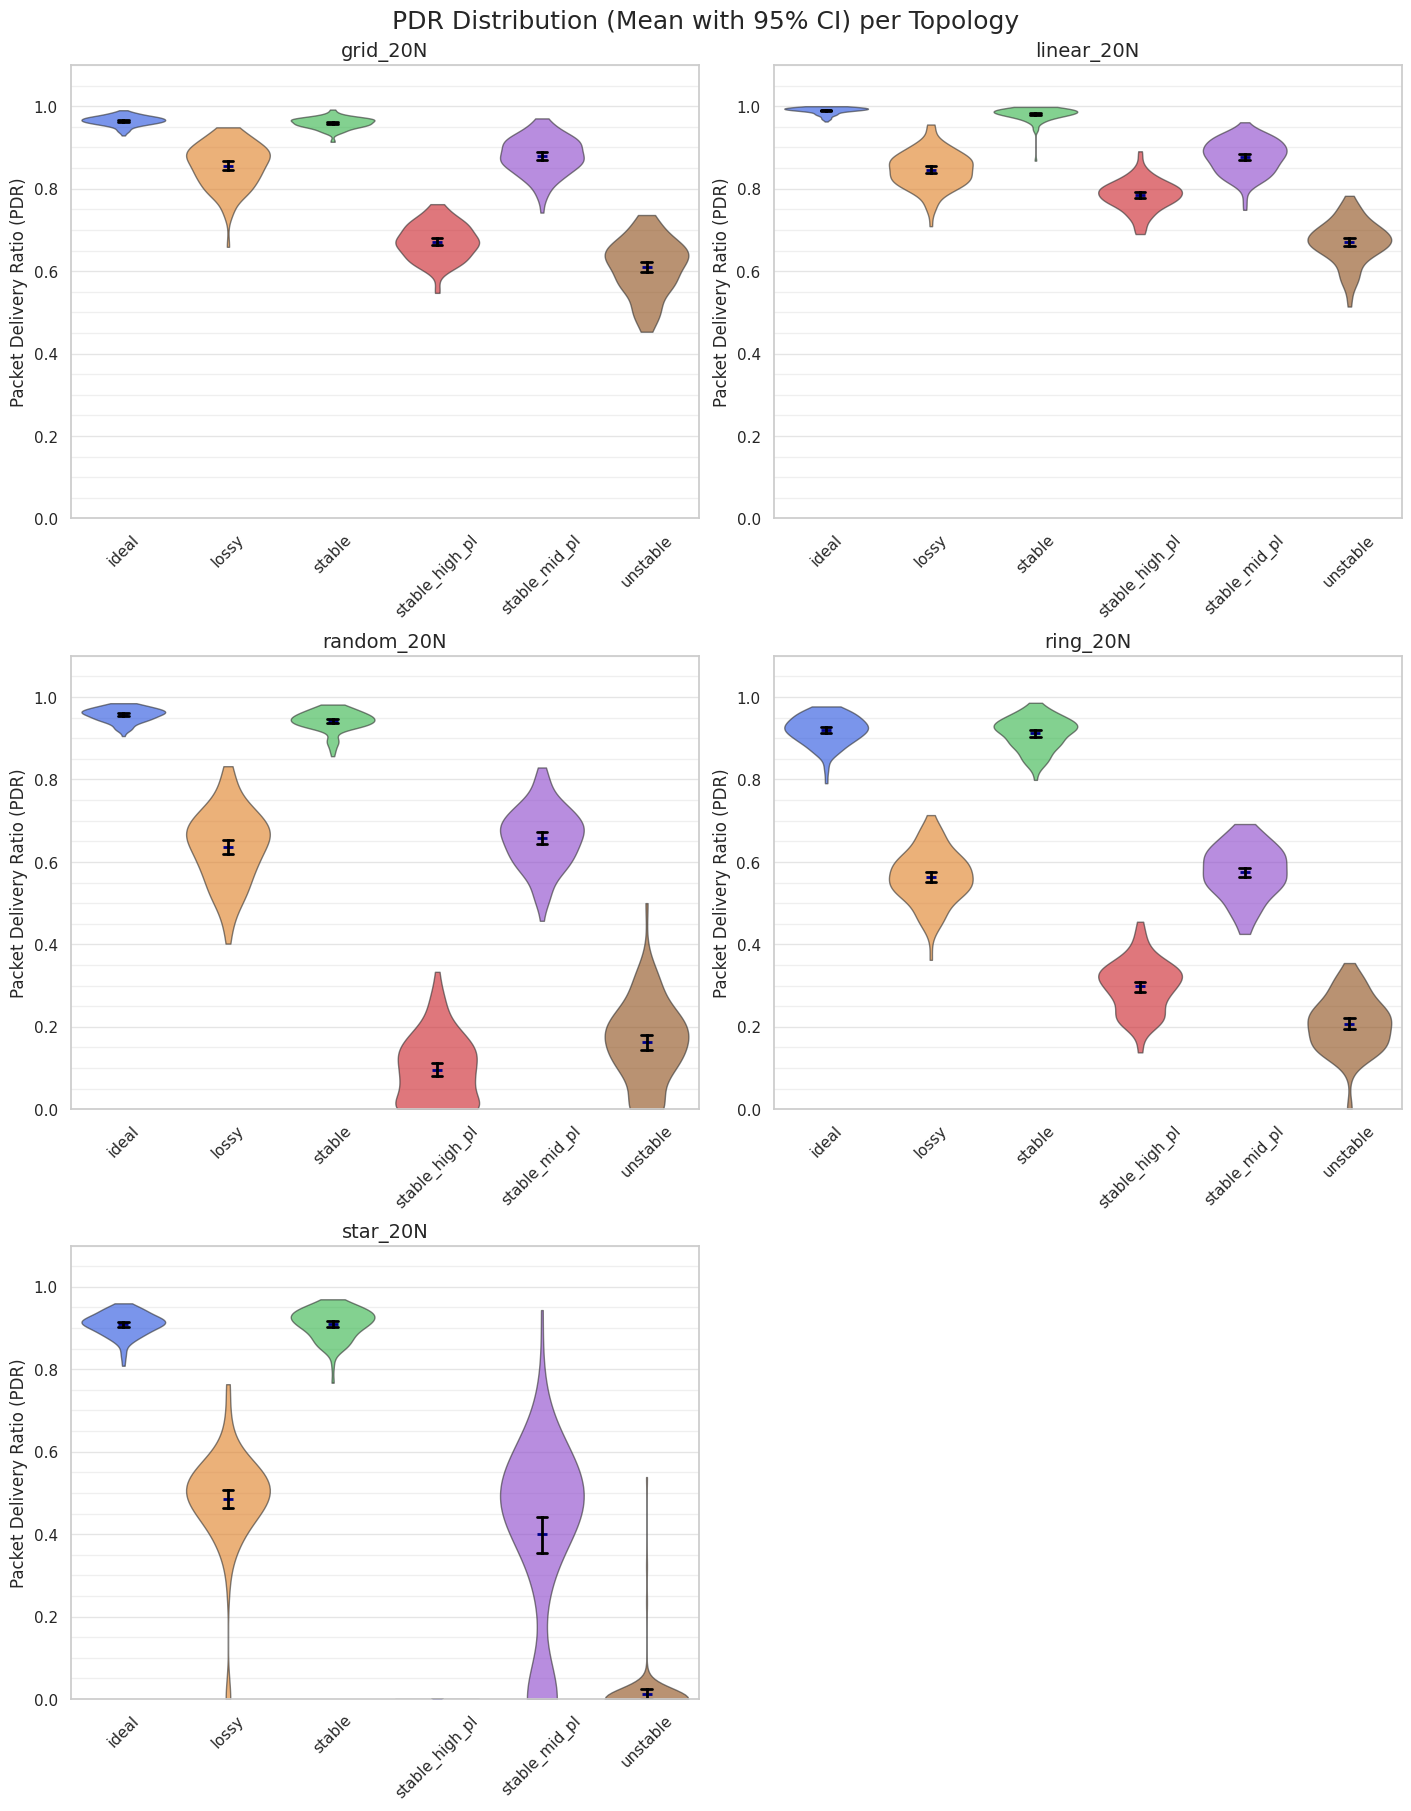

In [6]:
# ==============================================================================
# PLOT PDR
# ==============================================================================
plot_violin(
    metric_col="pdr", 
    title_prefix="PDR Distribution", 
    ylabel="Packet Delivery Ratio (PDR)", 
    ylim=(0, 1.1) # PDR is bounded 0-1
)

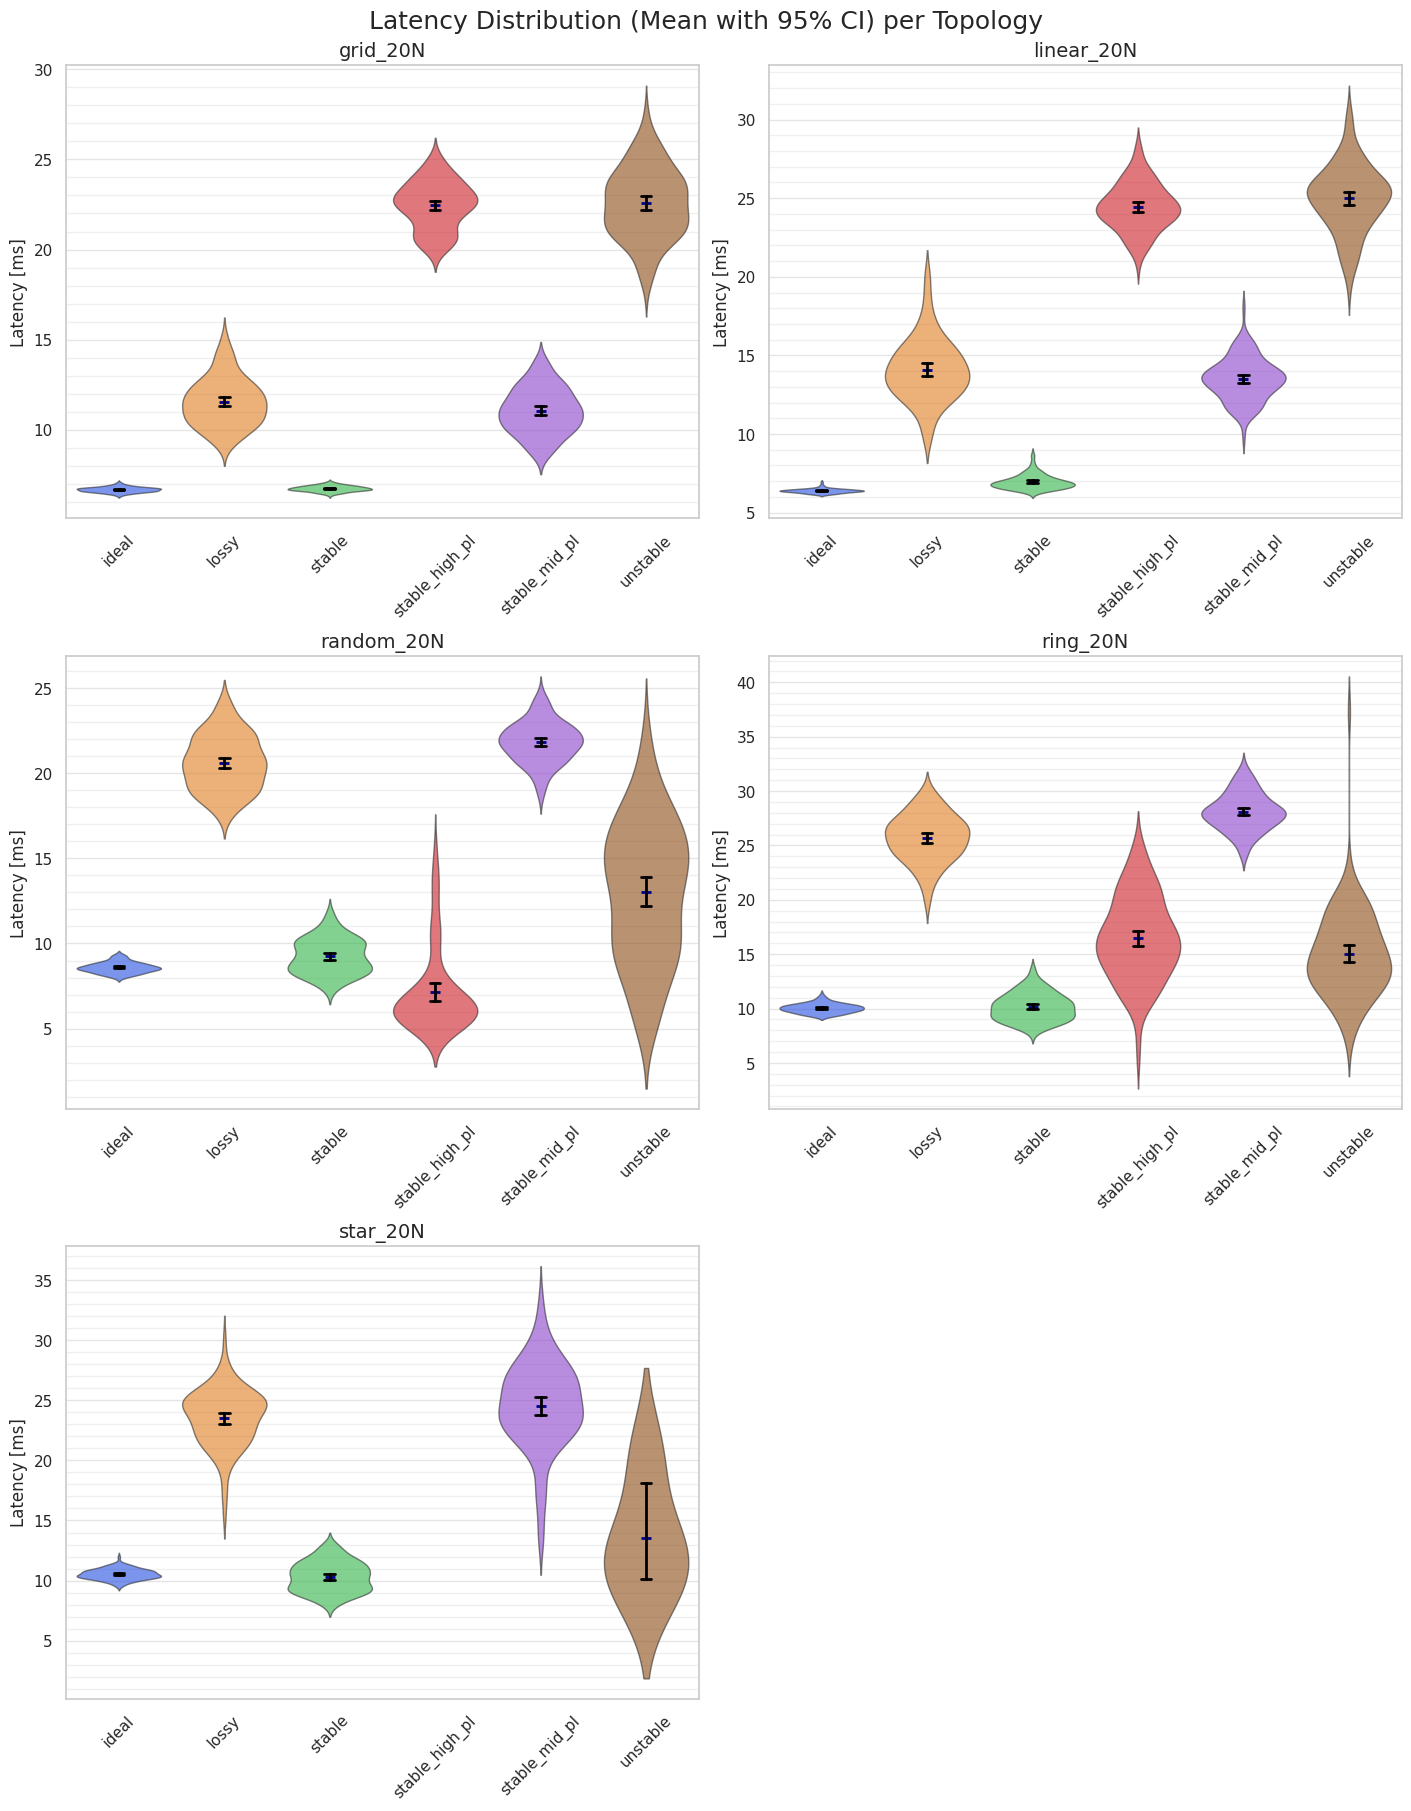

In [7]:
# ==============================================================================
# PLOT LATENCY
# ==============================================================================
plot_violin(
    metric_col="latency_ms", 
    title_prefix="Latency Distribution", 
    ylabel="Latency [ms]", 
    ylim=None
)

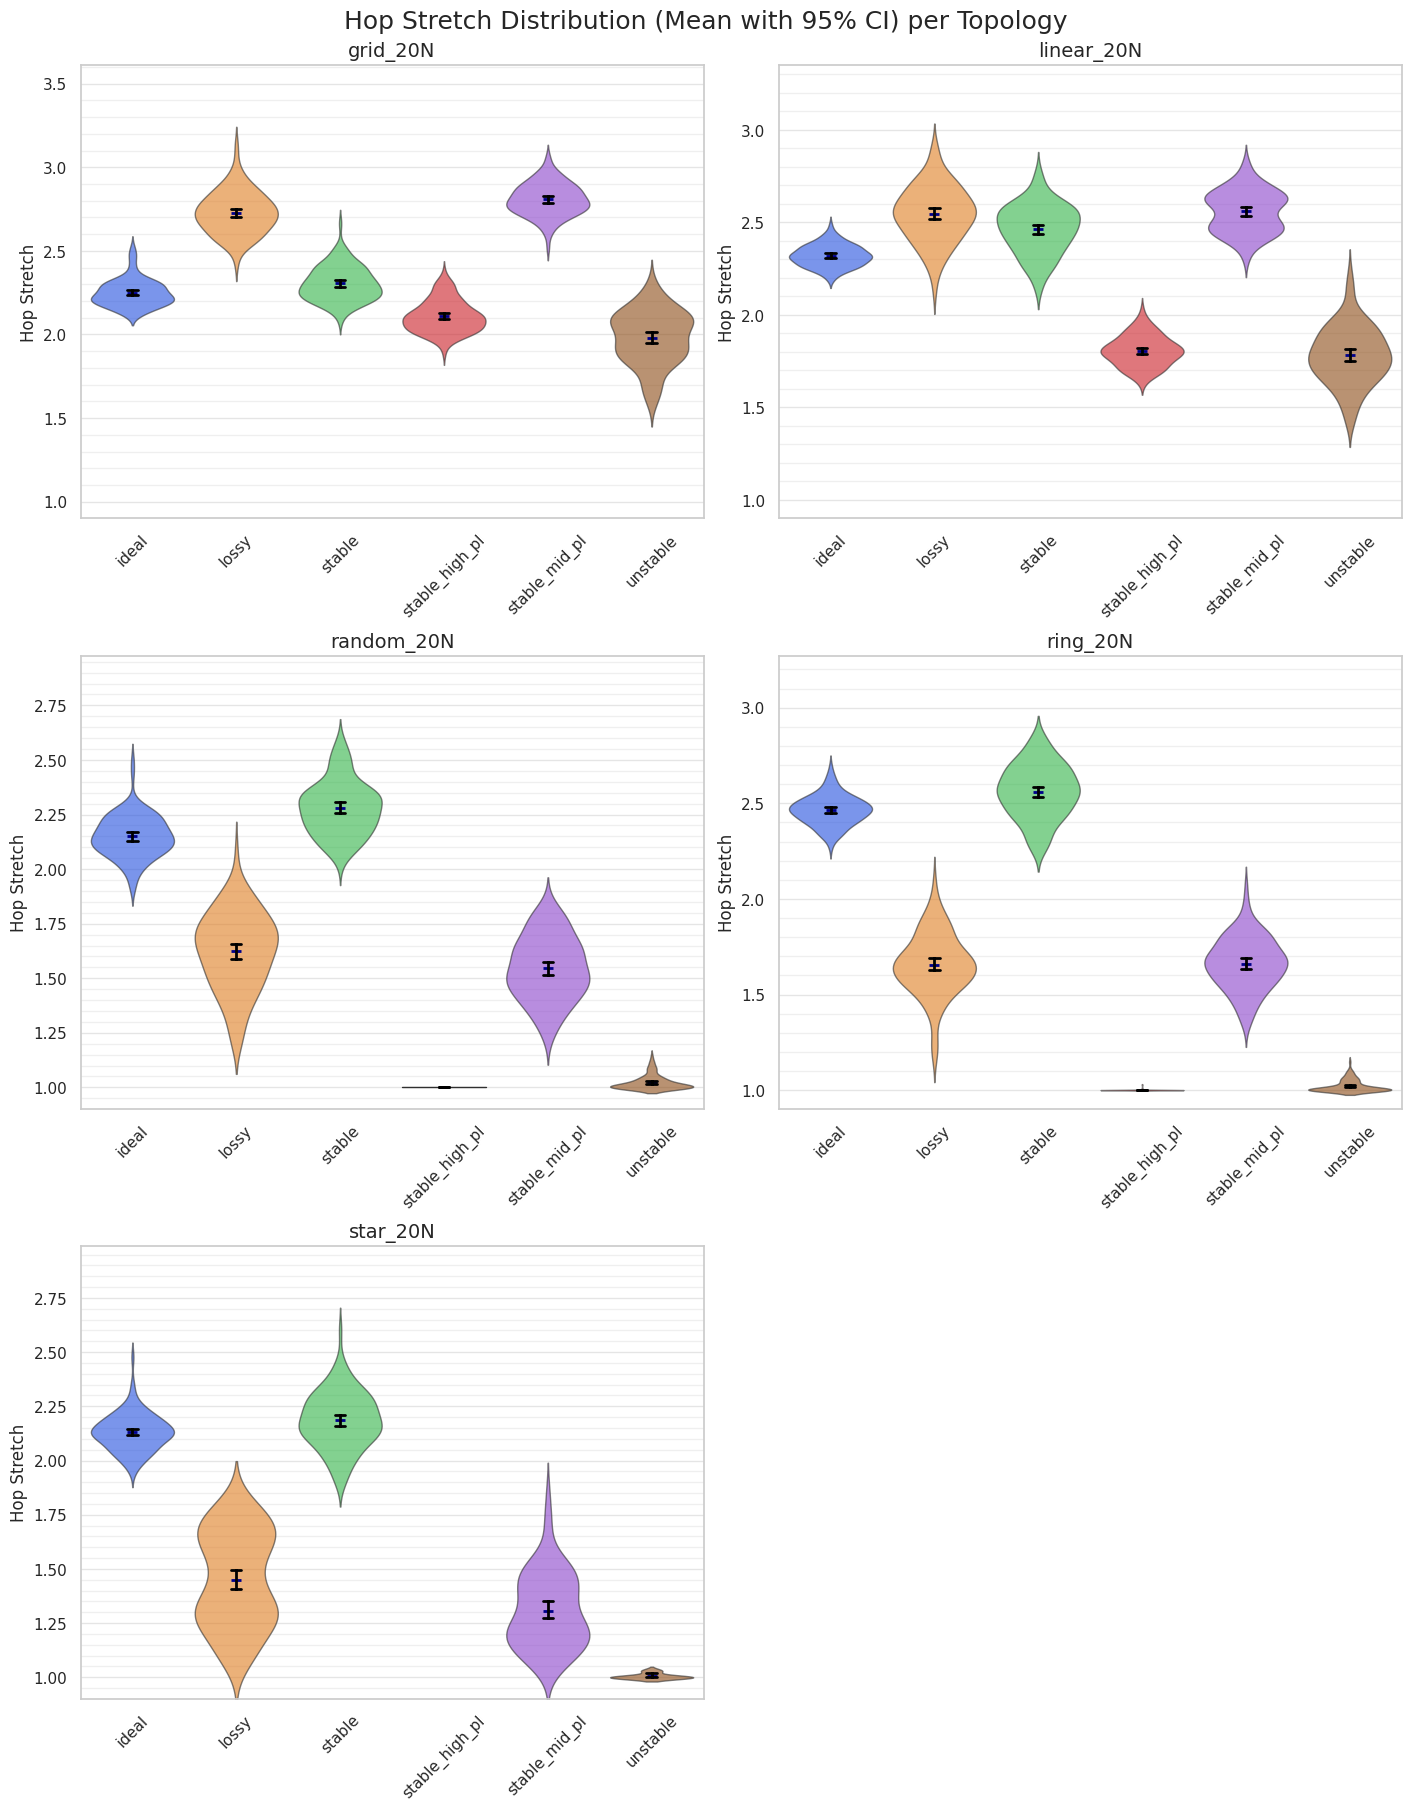

In [8]:
# ==============================================================================
# PLOT HOP STRETCH
# ==============================================================================
plot_violin(
    metric_col="hop_stretch", 
    title_prefix="Hop Stretch Distribution", 
    ylabel="Hop Stretch", 
    ylim=(0.9, None) # HS starts at 1, give a little buffer
)